In [2]:
# library used in assignment 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv("bmw.csv")
# to read the dataset

In [4]:
print(data.head())
print(data.tail())
print(data.shape)
print(data.columns)


       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  
           model  year  price transmission  mileage fuelType  tax   mpg  \
10776         X3  2016  19000    Automatic    40818   Diesel  150  54.3   
10777   5 Series  2016  14600    Automatic    42947   Diesel  125  60.1   
10778   3 Series  2017  13100       Manual    25468   Petrol  200  42.8   
10779   1 Series  2014   9930    Automatic    45000   Diesel   30  64.2   
10780         X1  2017  15981    Automatic    59432   Diesel  125  57.6   

       engineSize  
10776 

In [5]:
from scipy import stats

X_train_zscore = np.abs(stats.zscore(X_train))

outliers = (X_train_zscore > 3).any(axis=1)

print("Z-Score Analysis:")
print(f"Number of outliers detected: {outliers.sum()}")
print(f"Percentage of outliers: {(outliers.sum() / len(X_train)) * 100:.2f}%")

print("\nZ-scores (first 5 rows):")
print(X_train_zscore[:5])

X_train_clean = X_train[~outliers]
y_train_clean = y_train[~outliers]

print(f"\nDataset size after removing outliers: {X_train_clean.shape}")

NameError: name 'X_train' is not defined

In [ ]:
print(data.describe())


               year          price        mileage           tax           mpg  \
count  10781.000000   10781.000000   10781.000000  10781.000000  10781.000000   
mean    2017.078935   22733.408867   25496.986550    131.702068     56.399035   
std        2.349038   11415.528189   25143.192559     61.510755     31.336958   
min     1996.000000    1200.000000       1.000000      0.000000      5.500000   
25%     2016.000000   14950.000000    5529.000000    135.000000     45.600000   
50%     2017.000000   20462.000000   18347.000000    145.000000     53.300000   
75%     2019.000000   27940.000000   38206.000000    145.000000     62.800000   
max     2020.000000  123456.000000  214000.000000    580.000000    470.800000   

         engineSize  
count  10781.000000  
mean       2.167767  
std        0.552054  
min        0.000000  
25%        2.000000  
50%        2.000000  
75%        2.000000  
max        6.600000  


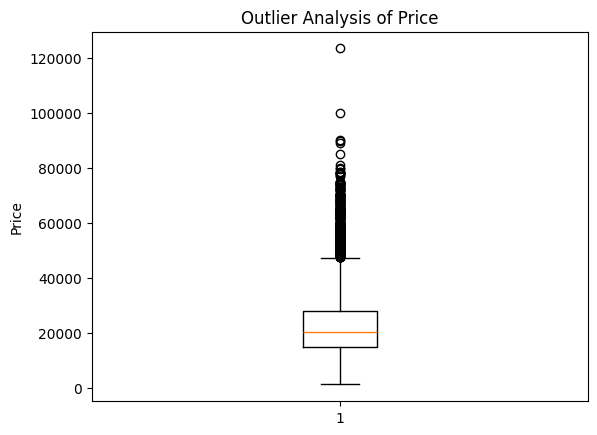

In [ ]:
plt.boxplot(data['price'])
plt.title("Outlier Analysis of Price")
plt.ylabel("Price")
plt.show()


In [6]:
median_price = np.median(data['price'])
q1 = np.percentile(data['price'], 25)
q3 = np.percentile(data['price'], 75)

In [7]:
print("--- Inference ---")
print("Median Price:", median_price)
print("Q1:", q1)
print("Q3:", q3)
print("High price outliers are present in the dataset.")

--- Inference ---
Median Price: 20462.0
Q1: 14950.0
Q3: 27940.0
High price outliers are present in the dataset.


In [ ]:
print("\nMissing Values:")
print(data.isnull().sum())



Missing Values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


In [ ]:
data.fillna(data.mean(numeric_only=True), inplace=True)


In [ ]:
X = data.drop('price', axis=1)
y = data['price']

print("Independent Variables (X):")
print(X.head())

print("\nDependent Variable (y):")
print(y.head())


Independent Variables (X):
       model  year transmission  mileage fuelType  tax   mpg  engineSize
0   5 Series  2014    Automatic    67068   Diesel  125  57.6         2.0
1   6 Series  2018    Automatic    14827   Petrol  145  42.8         2.0
2   5 Series  2016    Automatic    62794   Diesel  160  51.4         3.0
3   1 Series  2017    Automatic    26676   Diesel  145  72.4         1.5
4   7 Series  2014    Automatic    39554   Diesel  160  50.4         3.0

Dependent Variable (y):
0    11200
1    27000
2    16000
3    12750
4    14500
Name: price, dtype: int64


In [ ]:
print("Before Encoding:")
print(data[['model', 'transmission', 'fuelType']].head())


Before Encoding:
       model transmission fuelType
0   5 Series    Automatic   Diesel
1   6 Series    Automatic   Petrol
2   5 Series    Automatic   Diesel
3   1 Series    Automatic   Diesel
4   7 Series    Automatic   Diesel


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['model'] = le.fit_transform(data['model'])
data['transmission'] = le.fit_transform(data['transmission'])
data['fuelType'] = le.fit_transform(data['fuelType'])

print("\nAfter Encoding:")
print(data[['model', 'transmission', 'fuelType']].head())



After Encoding:
   model  transmission  fuelType
0      4             0         0
1      5             0         4
2      4             0         0
3      0             0         0
4      6             0         0


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('price', axis=1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (8624, 8)
Testing set size: (2157, 8)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)

print("Normalized data (first 5 rows):")
print(X_train_norm[:5])


Normalized data (first 5 rows):
[[0.17391304 0.58333333 0.         0.53041579 0.         0.4137931
  0.08166774 0.6       ]
 [0.56521739 0.95833333 0.5        0.01759355 1.         0.25
  0.10058027 0.3       ]
 [0.         0.83333333 0.         0.30176662 0.         0.05172414
  0.12314636 0.4       ]
 [0.65217391 0.95833333 1.         0.02736527 1.         0.25
  0.05351386 0.4       ]
 [0.         0.875      0.5        0.18997017 1.         0.25
  0.08768536 0.4       ]]


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)

print("Feature scaled data (first 5 rows):")
print(X_train_scaled[:5])


Feature scaled data (first 5 rows):
[[-0.21762031 -3.01743651 -1.27027702  2.76433524 -0.71335736  1.76708941
  -0.41768399  1.52595431]
 [ 1.26650395  0.80857026 -0.12124524 -0.88034704  1.45093248  0.21383589
  -0.12969688 -1.2243097 ]
 [-0.8772311  -0.46676533 -1.27027702  1.13930122 -0.71335736 -1.66641838
   0.2139241  -0.30755503]
 [ 1.59630934  0.80857026  1.02778655 -0.81089842  1.45093248  0.21383589
  -0.84639207 -0.30755503]
 [-0.8772311  -0.04165347 -0.12124524  0.34475191  1.45093248  0.21383589
  -0.32605173 -0.30755503]]


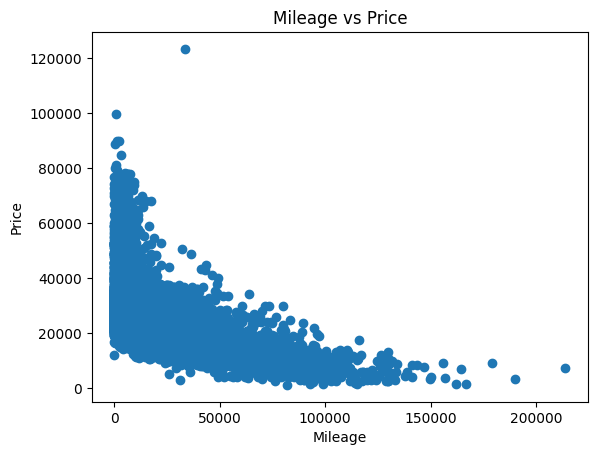

In [ ]:
plt.scatter(data['mileage'], data['price'])
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()


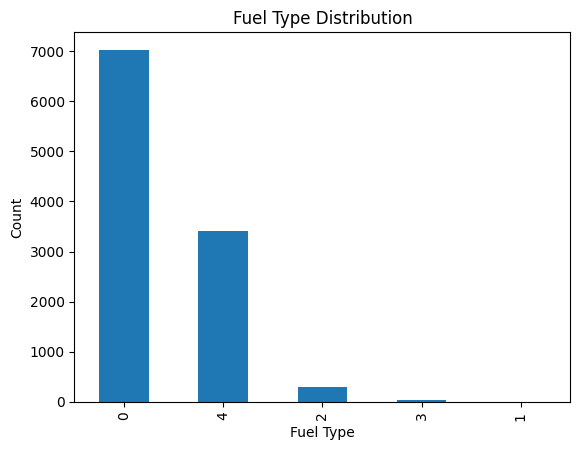

In [ ]:
data['fuelType'].value_counts().plot(kind='bar')
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()


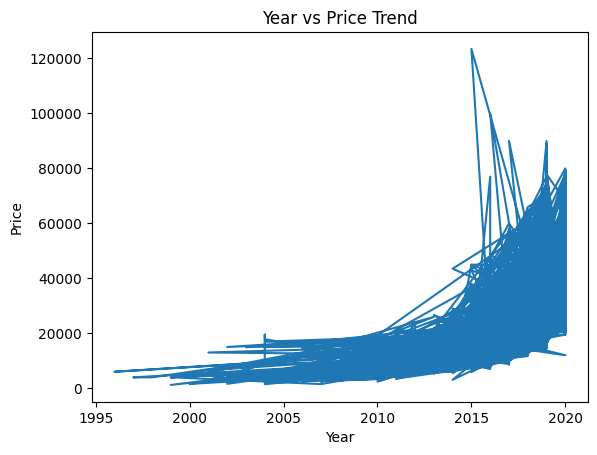

In [ ]:
plt.plot(data['year'], data['price'])
plt.title("Year vs Price Trend")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()


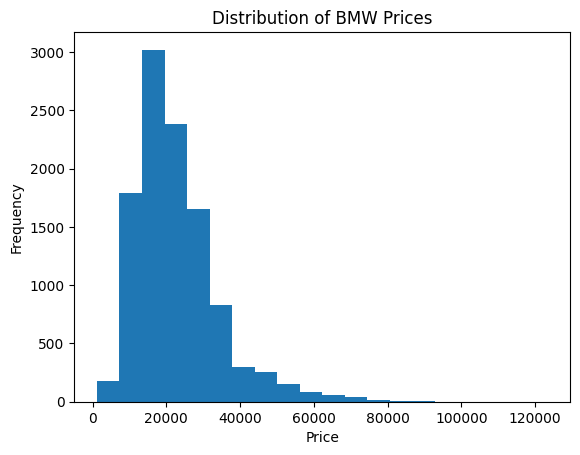

In [ ]:
plt.hist(data['price'], bins=20)
plt.title("Distribution of BMW Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


Thank You! 